# অধ্যায় ৪: ফিচার ইঞ্জিনিয়ারিং
## পাঠ ৪.২: বিনিং, ইন্টারঅ্যাকশন ও পলিনোমিয়াল ফিচার

আজ আমরা শিখব কীভাবে সাধারণ ফিচারগুলোকে আরও শক্তিশালী করা যায়। কল্পনা করো তুমি একজন শেফ। তুমি কি শুধু লবণ দিয়েই রান্না করো? না, তুমি বিভিন্ন মশলা মিশিয়ে জটিল স্বাদ তৈরি করো। ফিচার ইঞ্জিনিয়ারিং-ও ঠিক সেরকম—আমরা সাধারণ ফিচার নিয়ে সেগুলোকে বিভিন্নভাবে পরিবর্তন করে মডেলকে আরও স্মার্ট করি।

### A. বিনিং (Binning): সংখ্যাকে গ্রুপে ভাগ করা

ধরো তুমি তোমার বন্ধুদের বয়সের ডেটা সংগ্রহ করেছ:
- শিশু (০-৫ বছর), কিশোর (৬-১৭), তরুণ (১৮-৩০), প্রাপ্তবয়স্ক (৩১-৬০), বয়স্ক (৬০+)

এখানে আমরা বয়স নামক একটি সীমাহীন সংখ্যাকে ৫টি গ্রুপে ভাগ করেছি। একে 'বিনিং' বলে। বিনিং খুবই উপযোগী যখন ডেটার মধ্যে খুব বেশি তারতম্য থাকে না, কিন্তু গ্রুপভেদে প্যাটার্ন আলাদা হয়।

উদাহরণ: একটি লিনিয়ার মডেল বয়স এবং আয়ের মধ্যে সম্পর্ক খোঁজার চেষ্টা করছে। প্রকৃত সম্পর্ক হয়তো রৈখিক নয়—একজন ২০ বছর বয়সী এবং ৪০ বছর বয়সীর আয়ের পার্থক্য বেশি, কিন্তু ৪০ এবং ৬০ বছর বয়সীর মধ্যে পার্থক্য কম। বিনিং এই নন-লিনিয়ার সম্পর্ক ধরা সহজ করে।

In [1]:
# প্রয়োজনীয় লাইব্রেরি
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

# ডেটা তৈরি করি
np.random.seed(42)
X = np.random.uniform(0, 10, 200).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, 200)

# KBinsDiscretizer ব্যবহার করি
kbd = KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='uniform')
X_binned = kbd.fit_transform(X)
print('আসল ফিচারের আকৃতি:', X.shape)
print('বিনিংয়ের পর আকৃতি:', X_binned.shape)
print('\nপ্রথম 5টি নমুনার বিন:', X_binned[:5])

আসল ফিচারের আকৃতি: (200, 1)
বিনিংয়ের পর আকৃতি: (200, 5)

প্রথম 5টি নমুনার বিন: [[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]]


### B. KBinsDiscretizer-এর প্যারামিটার

- **n_bins**: কতটি বিন (গ্রুপ) তৈরি করবে
- **encode**: কিভাবে এনকোড করবে
  - `'onehot-dense'`: ওয়ান-হট এনকোডিং (সাধারণ অ্যারে)
  - `'onehot'`: স্পার্স ওয়ান-হট
  - `'ordinal'`: প্রতিটি বিনকে ০, ১, ২... সংখ্যা দেওয়া
- **strategy**: কিভাবে বিনের সীমানা নির্ধারণ করবে
  - `'uniform'`: সমান ব্যবধানে
  - `'quantile'`: প্রতিটি বিনে সমান সংখ্যক ডেটা পয়েন্ট
  - `'kmeans'`: কে-মিনস ক্লাস্টারিং ব্যবহার করে

### C. ইন্টারঅ্যাকশন ফিচার

কখনো কখনো দুটি ফিচারের সমন্বয়ে একটি নতুন ফিচার তৈরি করলে মডেল ভালো কাজ করে। যেমন:
- বাড়ির দাম = (বেডরুমের সংখ্যা) × (বর্গফুট)
- এই দুটো আলাদাভাবে না নিয়ে গুণ করে নেওয়াটা বেশি তথ্যবহুল হতে পারে

PolynomialFeatures আমাদের জন্য স্বয়ংক্রিয়ভাবে এই ইন্টারঅ্যাকশন ফিচার তৈরি করে দেয়।

In [2]:
# PolynomialFeatures ব্যবহার করি
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
print('আসল ফিচারের সংখ্যা:', poly.n_features_in_)
print('পলিনোমিয়াল ফিচারের সংখ্যা:', poly.n_output_features_)
print('ফিচারের নাম:', poly.get_feature_names_out())
print('\nপ্রথম 5টি নমুনা:', X_poly[:5])

আসল ফিচারের সংখ্যা: 1
পলিনোমিয়াল ফিচারের সংখ্যা: 2
ফিচারের নাম: ['x0' 'x0^2']

প্রথম 5টি নমুনা: [[ 3.74540119 14.02803006]
 [ 9.50714306 90.38576924]
 [ 7.31993942 53.58151308]
 [ 5.98658484 35.83919807]
 [ 1.5601864   2.43418162]]


### D. ডিগ্রি ২ দিয়ে কী কী ফিচার আসে?

যদি আসল ফিচার থাকে x₁, x₂, তাহলে ডিগ্রি ২ দিয়ে আমরা পাই:
- x₁, x₂ (আসল ফিচার)
- x₁², x₂² (স্কয়ার)
- x₁×x₂ (ইন্টারঅ্যাকশন)

**include_bias=False** দিলে ১ (কনস্ট্যান্ট) বাদ যায়। সাধারণত আমরা চাই না মডেলের ইন্টারসেপ্টের সাথে কনফিউশন হোক।

### E. বাস্তব উদাহরণ: লিনিয়ার মডেল বনাম পলিনোমিয়াল ফিচার

এখন আমরা দেখব কীভাবে পলিনোমিয়াল ফিচার একটি সাধারণ লিনিয়ার মডেলকে আরও শক্তিশালী করে তোলে। আমরা একটি সাইন ওয়েভ ডেটাসেট নেব এবং দেখব কোন মডেল ভালো ফিট করে।

In [3]:
# ডেটা ভাগ করি
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. সাধারণ লিনিয়ার রিগ্রেশন
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 2. পলিনোমিয়াল ফিচার + লিনিয়ার রিগ্রেশন
poly = PolynomialFeatures(degree=5, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)

# 3. বিনিং + লিনিয়ার রিগ্রেশন
kbd = KBinsDiscretizer(n_bins=10, encode='onehot-dense', strategy='uniform')
X_train_bin = kbd.fit_transform(X_train)
X_test_bin = kbd.transform(X_test)

lr_bin = LinearRegression()
lr_bin.fit(X_train_bin, y_train)
y_pred_bin = lr_bin.predict(X_test_bin)
print(f'লিনিয়ার রিগ্রেশন R²: {lr.score(X_test, y_test):.3f}')
print(f'পলিনোমিয়াল (ডিগ্রি 5) R²: {lr_poly.score(X_test_poly, y_test):.3f}')
print(f'বিনিং (10 বিন) R²: {lr_bin.score(X_test_bin, y_test):.3f}')

লিনিয়ার রিগ্রেশন R²: 0.004
পলিনোমিয়াল (ডিগ্রি 5) R²: 0.924
বিনিং (10 বিন) R²: 0.830


C:\Users\hp\AppData\Local\Temp\ipykernel_10096\1500857103.py:26: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_10096\1500857103.py:26: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_10096\1500857103.py:26: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_10096\1500857103.py:26: UserWarning: Glyph 2471 (\N{BENGALI LETTER DHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_10096\1500857103.py:26: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_10096\1500857103.py:26: UserWarning: Glyph 2467 (\N{BENGALI LETTER NNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2471 (\N{BENGALI LETTER DHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: Us

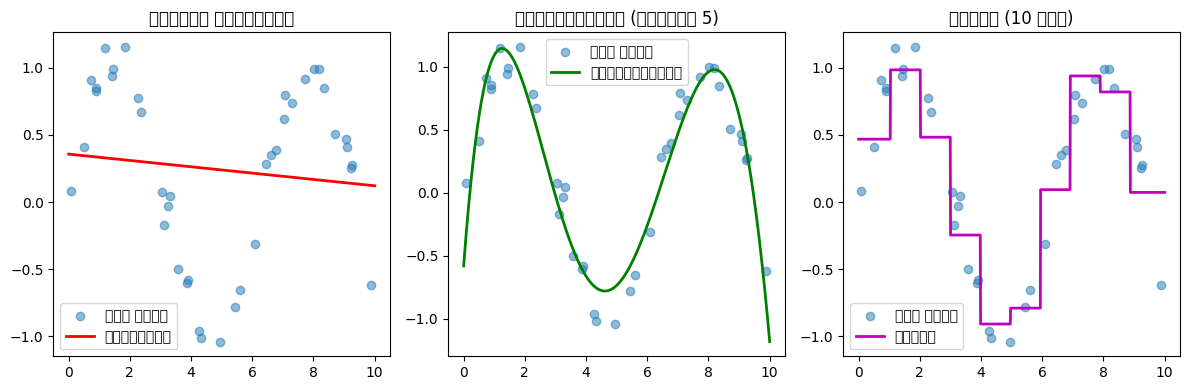

In [4]:
# ভিজুয়ালাইজ করি
X_plot = np.linspace(0, 10, 1000).reshape(-1, 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X_test, y_test, alpha=0.5, label='আসল ডেটা')
plt.plot(X_plot, lr.predict(X_plot), 'r-', label='লিনিয়ার', linewidth=2)
plt.title('সাধারণ লিনিয়ার')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X_test, y_test, alpha=0.5, label='আসল ডেটা')
X_plot_poly = poly.transform(X_plot)
plt.plot(X_plot, lr_poly.predict(X_plot_poly), 'g-', label='পলিনোমিয়াল', linewidth=2)
plt.title('পলিনোমিয়াল (ডিগ্রি 5)')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X_test, y_test, alpha=0.5, label='আসল ডেটা')
X_plot_bin = kbd.transform(X_plot)
plt.plot(X_plot, lr_bin.predict(X_plot_bin), 'm-', label='বিনিং', linewidth=2)
plt.title('বিনিং (10 বিন)')
plt.legend()

plt.tight_layout()
plt.show()

### F. ডিগ্রি বাছাই: আন্ডারফিটিং বনাম ওভারফিটিং

খেয়াল করো, পলিনোমিয়াল ফিচারের ডিগ্রি বাড়ালে মডেল আরও জটিল হয়। কিন্তু খুব বেশি ডিগ্রি দিলে মডেল ট্রেনিং ডেটা মুখস্থ করে ফেলে—একে ওভারফিটিং বলে। অন্যদিকে, খুব কম ডিগ্রি দিলে মডেল যথেষ্ট জটিল হয় না—একে আন্ডারফিটিং বলে।

**কৌশল:** ছোট ডিগ্রি (২ বা ৩) দিয়ে শুরু করো, তারপর প্রয়োজন বুঝে বাড়াও। ক্রস-ভ্যালিডেশন ব্যবহার করে সেরা ডিগ্রি বাছাই করো।

### G. কখন কী ব্যবহার করব?

| ফিচার ইঞ্জিনিয়ারিং | কখন ব্যবহার করব |
|---------------------|------------------|
| বিনিং | যখন ডেটার মান নয়, গ্রুপ গুরুত্বপূর্ণ |
| পলিনোমিয়াল | যখন ফিচারের মধ্যে বক্র সম্পর্ক আছে |
| ইন্টারঅ্যাকশন | যখন দুটি ফিচার একসঙ্গে প্রভাব ফেলে |

### H. তুমি কি বুঝতে পেরেছ?

**প্রশ্ন ১:** বিনিং কখন ব্যবহার করা উচিত?

**প্রশ্ন ২:** PolynomialFeatures ডিগ্রি ৩ দিলে কয়টি ফিচার পাওয়া যায় (২টি আসল ফিচার থাকলে)?

**প্রশ্ন ৩:** খুব বেশি ডিগ্রি ব্যবহার করলে কী সমস্যা হতে পারে?

**প্রশ্ন ৪:** KBinsDiscretizer-এর strategy='quantile' এবং 'uniform'-এর মধ্যে পার্থক্য কী?

### I. সারসংক্ষেপ

আজ আমরা শিখলাম:
✅ বিনিং সংখ্যাকে গ্রুপে ভাগ করে ফিচার সহজ করে
✅ পলিনোমিয়াল ফিচার লিনিয়ার মডেলকে নন-লিনিয়ার সম্পর্ক শিখতে সাহায্য করে
✅ ইন্টারঅ্যাকশন ফিচার দুটি ফিচারের সংমিশ্রণ তৈরি করে
✅ KBinsDiscretizer এবং PolynomialFeatures sklearn-এর দুটি শক্তিশালী টুল
✅ ডিগ্রি বাছাই করা গুরুত্বপূর্ণ—খুব কম বা খুব বেশি দুটোই খারাপ

পরবর্তী পাঠে আমরা ফিচার সিলেকশন নিয়ে শিখব—কীভাবে অপ্রয়োজনীয় ফিচার বাদ দিয়ে মডেলকে উন্নত করা যায়!